# SHS generation + analysis

In [1]:
# Sequence & structure 
RNA_SEQ =   "AUGCUACGAUCAGCUGAUCGAUGCGCGAUCGUAA"
STRUCTURE = "()()()()()()()()()()()()()()()()()"  # overrides the predictor if set
INTERACTIONS = "[[0, 1, 0.4], [2, 3, 0.4], [2, 4, 0.4], [4, 3, 0.4], [5, 6, 1], [5, 7, 1], [6, 7, 1], [8, 9, 0.4], [8, 10, 0.4], [11, 12, 1], [11, 13, 1], [14, 15, 0.4], [15, 16, 0.4], [17, 18, 1], [18, 19, 1], [20, 22, 0.4], [21, 22, 0.4], [23, 25, 1], [24, 25, 1], [26, 27, 1], [27, 28, 1], [28, 29, 1], [29, 30, 1], [30, 31, 1], [31, 32, 1], [32, 33, 1]]"
# INTERACTIONS = None
MUTATION_RATES = None
STRUCTURE_PREDICTOR = "rnafold"          # rnafold, spotrna, rnaformer

# MSA size / reproducibility 
N = 10000
SEED = 42

# Mutation parameters
MUTATION_RATE_UNPAIRED = 0.1
MUTATION_RATE_PAIRED   = 0.3
PAIR_MUTATION_APPROACH = "covariance" # covariance | watson_crick | watson_crick_cov | original | none

# Triplet Mutation parameter for "original" mutation approach
WOBBLE_PROB            = 0.0 # 0.1 

# insertions / deletions - general
MAX_INSERTION_FRACTION = 0.2 # 0.1
MAX_DELETION_FRACTION  = 0.1 # 0.1
# paired
STEM_SINGLE_INSERTION_PROB  = 0.05
STEM_LONG_INSERTION_PROB    = 0.01 # 0.05
STEM_SINGLE_DELETION_PROB   = 0.1
STEM_PAIR_DELETION_PROB     = 0.2

# unpaired
LOOP_SINGLE_INSERTION_PROB = 0.1 # 0.2
LOOP_SINGLE_DELETION_PROB  = 0.3 # 0.8
LOOP_LONG_INSERTION_PROB   = 0.1 # 0.05
LOOP_LONG_DELETION_PROB    = 0.05 # 0.05

# Optional identifier for structure prediction
PDB_ID = "None"

## Setup

In [2]:
import importlib
import os
import sys
from pathlib import Path

%matplotlib inline

_candidates = [Path.cwd(), Path.cwd() / "SHS-Generator"]
SHS_DIR = next((p for p in _candidates if (p / "shs_generator.py").exists()), None)
if SHS_DIR is None:
    raise FileNotFoundError("Could not find shs_generator.py.")
SHS_DIR = SHS_DIR.resolve()
os.chdir(SHS_DIR)
if str(SHS_DIR) not in sys.path:
    sys.path.insert(0, str(SHS_DIR))

import pair_map
import generator_config
import json_generator
import shs_generator
import shs_analyzer
importlib.reload(pair_map)
importlib.reload(generator_config)
importlib.reload(json_generator)
importlib.reload(shs_generator)
importlib.reload(shs_analyzer)

print("SHS-Generator dir:", SHS_DIR)

SHS-Generator dir: /home/kaii/bachelor_project/SyntheticEvolution/SHS-Generator


## Generate the SHS

In [ ]:
if INTERACTIONS is not None:
    structure_input = shs_generator.parse_json(INTERACTIONS) if isinstance(INTERACTIONS, str) else INTERACTIONS
elif STRUCTURE:
    structure_input = STRUCTURE
else:
    import structure_predictor
    structure_input = structure_predictor.predict(STRUCTURE_PREDICTOR, RNA_SEQ, PDB_ID)

per_position_rates = (
    shs_generator.parse_json(MUTATION_RATES)
    if isinstance(MUTATION_RATES, str) else MUTATION_RATES
)
pair_map = generator_config.build_pair_map(
    RNA_SEQ, structure_input,
    mutation_rate_paired=MUTATION_RATE_PAIRED,
    mutation_rate_unpaired=MUTATION_RATE_UNPAIRED,
    mutation_rates=per_position_rates,
)

# Only global algorithm settings belong in MutationParameters.
parameters = generator_config.MutationParameters(
    N=N,
    pair_mutation_approach=PAIR_MUTATION_APPROACH,
    stem_single_insertion_prob=STEM_SINGLE_INSERTION_PROB,
    stem_long_insertion_prob=STEM_LONG_INSERTION_PROB,
    stem_single_deletion_prob=STEM_SINGLE_DELETION_PROB,
    stem_pair_deletion_prob=STEM_PAIR_DELETION_PROB,
    loop_single_insertion_prob=LOOP_SINGLE_INSERTION_PROB,
    loop_single_deletion_prob=LOOP_SINGLE_DELETION_PROB,
    loop_long_insertion_prob=LOOP_LONG_INSERTION_PROB,
    loop_long_deletion_prob=LOOP_LONG_DELETION_PROB,
    max_insertion_fraction=MAX_INSERTION_FRACTION,
    max_deletion_fraction=MAX_DELETION_FRACTION,
    wobble_prob=WOBBLE_PROB,
)
generator = shs_generator.MsaGenerator(parameters, seed=SEED)
msa = generator.generate(RNA_SEQ, pair_map)

# JSON construction is separate from generation. This notebook does not save it.
generated_json = json_generator.build_input_json(
    RNA_SEQ, msa, name="notebook_rna", model_seeds=[1],
)
print("Generated", len(msa), "MSA rows for", len(RNA_SEQ), "RNA positions")


Generated 10000 MSA rows for 34 RNA positions


## Analyze & render

Query length: 34  |  MSA rows: 10000  |  covariance shape: (34, 34)
AUGCUACGAUCAGCUGAUCGAUGCGCGAUCGUAA
-U-AcggGGUGAACGCUUUAUCGACGGGGAUUUCCAC
AAg-AUACGAACAG-GGUC-G-UUCGCGgAUCUUgucAuaA
--GCAACGAACAuGCCGAUCGAUGCG-uGAU-UUGA
AUGCAACgccuCAUCAGCU--UAGGUCC-GUCUCGUAA
AUGCUACGAUCUA-CGAU-AgGUGCGCC--CGUAA
aAUGCUACGAUCAGCCGAuGCgGAUU-GCGAGUGUuCA
AGuGCCACG-UCUGCUGAUGGUCGUGCGAgAAGUAUg
uCU-CU-UCCUCAGCCGGCAG-AAGGG-CGCAGCa-g
AAGUGACG-UCAGUAGAAu-GACGCUGGAUUAUAgA
AUGCUCCUAA-AG-UUAUucuaCGAaGCCGC-AUCGUA-


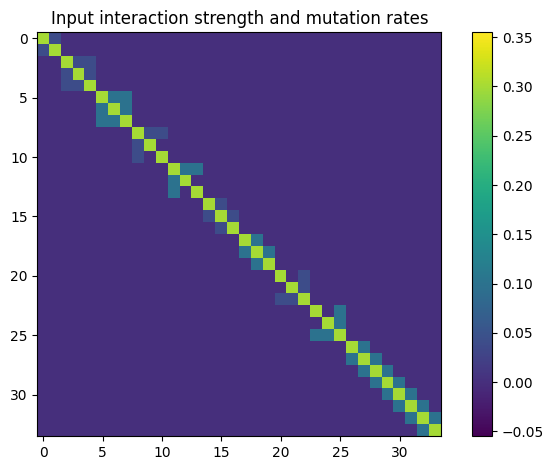

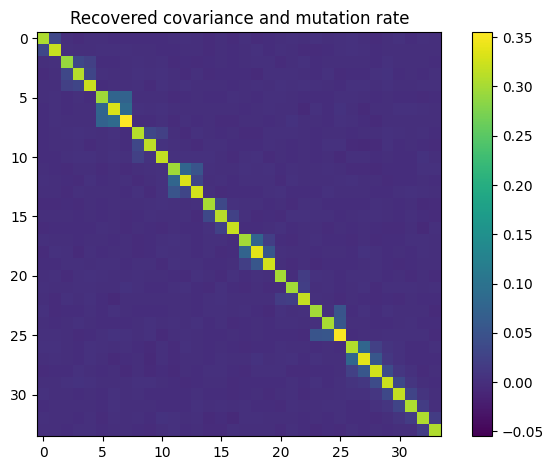

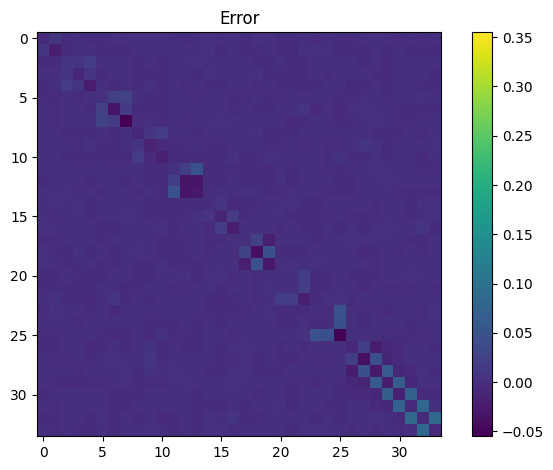

In [4]:
import json
import numpy as np

data = shs_analyzer.MsaData.from_text(json.dumps(generated_json), pairs=pair_map)
feat = shs_analyzer.Features(data)

print(f"Query length: {len(data.seq)}  "
   f"|  MSA rows: {data.aligned.shape[0] + 1}  "
   f"|  covariance shape: {feat.covariance.shape}")

print(data.seq)
for row in data.raw[:10]:
    print("".join(row))

expectation = data.pairs._pairs_mat.copy()
expectation[~np.eye(expectation.shape[0], dtype=bool)] *= 0.1
error = expectation - feat.covariance
vmin, vmax = min(error.min(), expectation.max(), feat.covariance.min()), max(error.max(), expectation.max(), feat.covariance.max())
shs_analyzer.plot_covariance(data.seq, expectation, title="Input interaction strength and mutation rates", show_values=False, vmin=vmin, vmax=vmax)
shs_analyzer.plot_covariance(data.seq, feat.covariance, show_values=False, vmin=vmin, vmax=vmax)
_ = shs_analyzer.plot_covariance(data.seq, error, title="Error", show_values=False, vmin=vmin, vmax=vmax)

## Covariance per pair

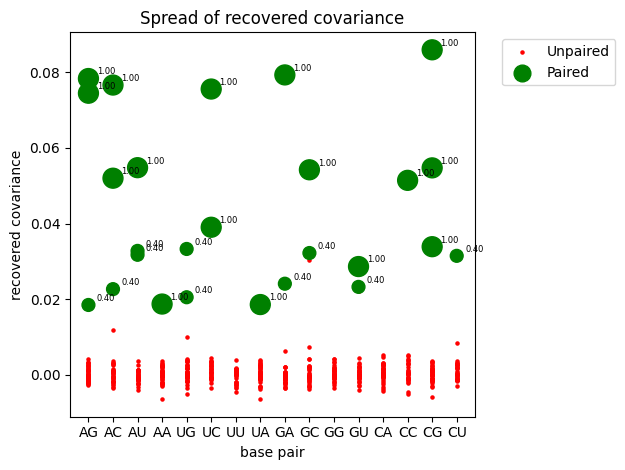

In [5]:
_ = shs_analyzer.plot_covariance_classification(data.seq, feat.covariance, pairs=data.pairs)

## Deletion and Insertion analysis

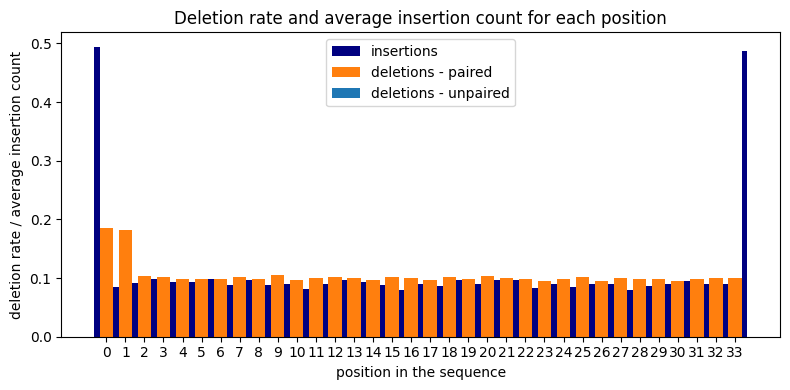

In [6]:
_ = shs_analyzer.plot_deletions_and_insertion(feat.col_deletion_rate, feat.col_insertion_mean, pairs=data.pairs)

## Mutation-rate comparison

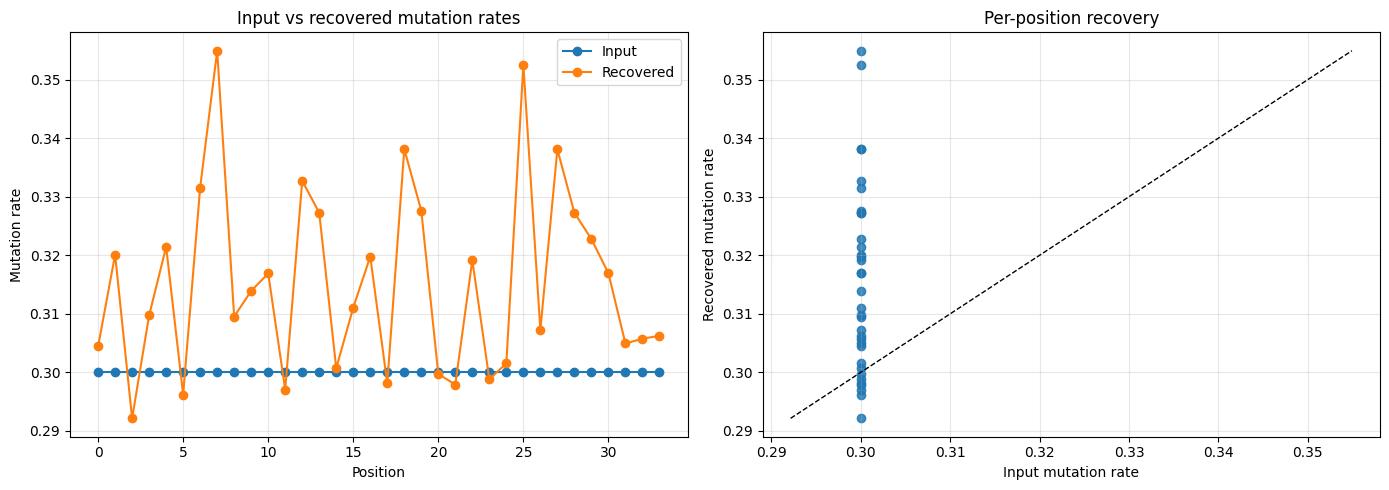

MAE: 0.0165 | RMSE: 0.0220 | Pearson r: 0.0000


In [7]:
# PairMap stores the effective rates, including scalar defaults and overrides.
input_rates = np.array([pair_map.mutation_rate(i) for i in range(len(data.seq))])
output_rates = feat.col_mut_rate
fig, metrics = shs_analyzer.plot_mutation_rate_comparison(input_rates, output_rates)
print(f"MAE: {metrics['mae']:.4f} | RMSE: {metrics['rmse']:.4f} | Pearson r: {metrics['pearson_r']:.4f}")


## Recovered parameters

In [8]:
import pandas as pd

# Show full cell contents so the `detail` strings aren't truncated.
pd.set_option("display.max_colwidth", None)
pd.set_option("display.width", None)

# Known generator input per recovered parameter name (the ground truth each
# estimator tries to reproduce). Extend this as you add estimators.
KNOWN_INPUTS = {
    "n_sequences":            N,
    "mutation_rate_unpaired": MUTATION_RATE_UNPAIRED,
    "mutation_rate_paired":   MUTATION_RATE_PAIRED,
}

report = shs_analyzer.analyze_data(data)


def _fmt_detail(detail):
    # Turn {'unpaired_cols': 14, ...} into a readable "unpaired_cols=14 · ..." line.
    return " · ".join(f"{k}={v}" for k, v in detail.items())


rows = []
for name, est in report.items():
    known = KNOWN_INPUTS.get(name)
    # est.value != est.value is True only for NaN -> no error there.
    error = abs(est.value - known) if (known is not None and est.value == est.value) else None
    rows.append({
        "parameter": name,
        "known":     known,
        "recovered": round(est.value, 4),
        "abs_error": round(error, 4) if error is not None else None,
        "detail":    _fmt_detail(est.detail),
    })

pd.DataFrame(rows).set_index("parameter")

,known,recovered,abs_error,detail
parameter,,,,
n_sequences,10000.0,10000.0000,0.0000,
mutation_rate_unpaired,0.1,NaN,NaN,unpaired_cols=0 · structure_known=True
mutation_rate_paired,0.3,0.3154,0.0154,paired_cols=34 · structure_known=True
